# SCNN interoperability experiment: paper reproduction with NeuroHLS

This notebook imports the official Sinabs-exported SCNN graph, generates a **time-driven** NeuroHLS implementation, runs it through CSim, and compares output accuracy and first-IF activity with the paper artefacts.

It uses `cnn_numbers.npy` for the first-IF activity comparison and the full official N-MNIST test set for accuracy, matching the two dataset paths used in `nir_paper/02_cnn/snntorch_apply.ipynb`.


In [1]:
from pathlib import Path
import os, sys
import numpy as np
import pandas as pd
cwd = Path.cwd().resolve()
repo_root = cwd if (cwd / 'neuro_hls').is_dir() else cwd.parent
sys.path.insert(0, str(repo_root / 'validation'))
import common as vc
import matplotlib.pyplot as plt
RUN_CSIM = vc.env_flag('NEUROHLS_RUN_CSIM', True)
FORCE = vc.env_flag('NEUROHLS_FORCE', False)
TIMEOUT_MINUTES = vc.env_int('NEUROHLS_TIMEOUT_MINUTES', 420)
USE_FLOAT = os.environ.get('NEUROHLS_ARITHMETIC', 'float').casefold() == 'float'
ALLOW_LARGE_DOWNLOAD = vc.env_flag('NEUROHLS_DOWNLOAD_LARGE_REFERENCE_ACTIVITY', False)

# Paper activity set used for the first-IF comparison.
activity_set_path = vc.NIR_EXAMPLES / 'cnn_numbers.npy'
activity_set = np.load(activity_set_path, mmap_mode='r')
if activity_set.shape != (300, 10, 2, 34, 34):
    raise ValueError(f'Unexpected cnn_numbers.npy shape: {activity_set.shape}')
ACTIVITY_SAMPLES = activity_set.shape[1]
activity_scope = 'paper activity set: one example per digit, 300 fixed steps'
print(f'Paper activity set: {activity_set.shape}')
print(f'Usando {ACTIVITY_SAMPLES} amostras (total: {activity_set.shape[1]})')

# Full N-MNIST test set used for the accuracy result. Its shape is read from
# the .npy header inside the archive: indexing the member instead would
# decompress the whole 14.5 GB array just to read a dimension.
full_dataset_path = vc.NIR_EXAMPLES / 'n-mnist-314-steps-10000-1ms.npz'
full_dataset_shape, _ = vc.npz_member_shape(full_dataset_path, 'data')
total_samples = int(full_dataset_shape[0])
total_steps = int(full_dataset_shape[1])
ACCURACY_SAMPLES = total_samples
accuracy_scope = (
    f'official N-MNIST test set: {ACCURACY_SAMPLES} of {total_samples} samples, '
    f'same partition and 1 ms time-window framing as the reference libraries '
    f'({total_steps} zero-padded steps)'
)
print(f'Full N-MNIST dataset: {total_samples} samples, {total_steps} steps')
print(f'Usando {ACCURACY_SAMPLES} amostras (total: {total_samples})')
print(f'activity_scope: {activity_scope}')
print(f'accuracy_scope: {accuracy_scope}')


Paper activity set: (300, 10, 2, 34, 34)
Usando 10 amostras (total: 10)
Full N-MNIST dataset: 10000 samples, 314 steps
Usando 10000 amostras (total: 10000)
activity_scope: paper activity set: one example per digit, 300 fixed steps
accuracy_scope: official N-MNIST test set: 10000 of 10000 samples, same partition and 1 ms time-window framing as the reference libraries (314 zero-padded steps)


## Generate and execute the model

The validation project adds an output probe after the first IF layer. The CSim testbench accumulates its 16×16×16 spike tensor over the 300 logical steps without changing the generated neuron/operator calls.

In [2]:
activity_project, activity_sample_count, activity_scope, activity_dataset_path = vc.generate_scnn_project(
    mode='numbers', samples=ACTIVITY_SAMPLES, use_float=USE_FLOAT, probe=True, force=FORCE
)
activity_run_dir = vc.run_csim(activity_project, timeout_minutes=TIMEOUT_MINUTES, execute=RUN_CSIM, force=FORCE)
activity_rates = vc.parse_scnn_rates(activity_run_dir)
activity_rates.to_csv(vc.RESULTS_ROOT / 'scnn_neurohls_first_if_rates.csv', index=False)
vc.save_json(vc.RESULTS_ROOT / 'scnn_csim_summary.json', vc.run_summary(activity_run_dir))
vc.save_json(
    vc.RESULTS_ROOT / 'scnn_provenance.json',
    vc.provenance(
        {'nir': vc.NIR_EXAMPLES / 'cnn_sinabs.nir', 'dataset': activity_dataset_path},
        backend='time-driven', parallelism_p=0.0,
        arithmetic='float' if USE_FLOAT else 'fixed-point',
        samples=activity_sample_count, steps=300, dataset_scope=activity_scope,
        run_dir=str(activity_run_dir), probe='first IF output',
    ),
)
print(f'Activity CSim run: {activity_run_dir}')


Activity CSim run: /home/rcarlos/Documentos/SNN/Renan/NeuroHLS_dev/validation/runs/scnn_numbers_10_float_probe/20260819T012626Z-1f03c6fb80b2


In [3]:
import json
import shutil
from concurrent.futures import ThreadPoolExecutor, as_completed

# The full 10,000-sample N-MNIST accuracy run generates a CSim testbench
# text file large enough to fill the disk (~14 GB in ASCII). Split it into
# batches so each CSim invocation only materialises a small slice of the
# dataset, and delete each batch's generated artefacts right after reading
# its result.
ACCURACY_BATCH_SIZE = 100

# CSim is single-threaded and peaks around 250 MiB per Vitis process, so the
# batches run concurrently. Throughput saturates on memory bandwidth well
# before it saturates the cores: measured on this host (12 cores), 1 worker
# gives 0.19 samples/s, 4 give 0.48 (2.5x) and 8 give 0.65 (3.4x), at ~1.1 GB
# peak RSS. Each in-flight batch also materialises a ~140 MB data.txt. Six is
# the default so the machine stays usable; raise it with
# NEUROHLS_ACCURACY_WORKERS on an idle host.
ACCURACY_WORKERS = vc.env_int('NEUROHLS_ACCURACY_WORKERS', 6)

ACCURACY_SUMMARY_PATH = vc.RESULTS_ROOT / 'scnn_accuracy_csim_summary.json'
ACCURACY_PROVENANCE_PATH = vc.RESULTS_ROOT / 'scnn_accuracy_provenance.json'


def saved_accuracy_sweep():
    """Return a completed sweep to reuse, or None if it must be recomputed.

    This sweep costs hours of CSim, so finishing it once should be enough: a
    kernel restart or a re-run of the notebook should not pay for it again.
    The saved result is only reused when its provenance matches what this
    notebook is configured to measure -- same dataset file, same sample count,
    same arithmetic. Anything else is recomputed rather than reported, so a
    result from a different dataset can never be presented as this one's.
    Set NEUROHLS_FORCE=1 to recompute regardless.
    """
    if FORCE:
        return None
    if not (ACCURACY_SUMMARY_PATH.is_file() and ACCURACY_PROVENANCE_PATH.is_file()):
        return None

    summary = json.loads(ACCURACY_SUMMARY_PATH.read_text())
    provenance = json.loads(ACCURACY_PROVENANCE_PATH.read_text())
    configuration = provenance.get('configuration') or {}
    saved_dataset = ((provenance.get('inputs') or {}).get('dataset') or {}).get('path', '')

    mismatches = []
    if Path(saved_dataset).name != full_dataset_path.name:
        mismatches.append(f'dataset {Path(saved_dataset).name!r} != {full_dataset_path.name!r}')
    if summary.get('samples_evaluated') != ACCURACY_SAMPLES:
        mismatches.append(f'samples {summary.get("samples_evaluated")} != {ACCURACY_SAMPLES}')
    expected_arithmetic = 'float' if USE_FLOAT else 'fixed-point'
    if configuration.get('arithmetic') != expected_arithmetic:
        mismatches.append(f'arithmetic {configuration.get("arithmetic")!r} != {expected_arithmetic!r}')
    if summary.get('correct') is None:
        mismatches.append('saved summary has no correct count')

    if mismatches:
        print('Saved accuracy sweep does not match this configuration, recomputing:')
        for mismatch in mismatches:
            print(f'  - {mismatch}')
        return None
    return summary, provenance


def run_accuracy_batch(batch_offset):
    batch_samples = min(ACCURACY_BATCH_SIZE, ACCURACY_SAMPLES - batch_offset)
    batch_project, batch_count, _, _ = vc.generate_scnn_project(
        mode='nmnist', samples=batch_samples, offset=batch_offset,
        use_float=USE_FLOAT, probe=False, force=FORCE,
    )
    batch_run_dir = vc.run_csim(
        batch_project, timeout_minutes=TIMEOUT_MINUTES, execute=RUN_CSIM, force=FORCE
    )
    batch_accuracy = vc.csim_accuracy(batch_run_dir)
    batch_correct = round(batch_accuracy / 100.0 * batch_count)
    result = (batch_offset, batch_count, batch_accuracy, batch_correct, str(batch_run_dir))
    if RUN_CSIM:
        # Free the heavy CSim artefacts (tb_data/data.txt, vitis_proj). The
        # cached batch dataset is kept: it is small and makes a resume cheap.
        shutil.rmtree(batch_run_dir, ignore_errors=True)
        shutil.rmtree(batch_project, ignore_errors=True)
    return result


reused = saved_accuracy_sweep()

if reused is not None:
    accuracy_summary, accuracy_provenance = reused
    total_correct = accuracy_summary['correct']
    total_evaluated = accuracy_summary['samples_evaluated']
    accuracy_batch_run_dirs = accuracy_summary.get('run_dirs', [])
    accuracy_sample_count = total_evaluated
    accuracy = 100.0 * total_correct / total_evaluated
    accuracy_steps = accuracy_provenance['configuration']['steps']
    accuracy_run_dir = Path(accuracy_provenance['configuration']['run_dir'])
    print(
        f'Reusing the saved accuracy sweep from {accuracy_provenance["created_at"]} '
        f'({accuracy_summary.get("batches", "?")} batches). '
        f'Set NEUROHLS_FORCE=1 to recompute.'
    )
else:
    # One pass over the 14.5 GB archive writes every batch window. Preparing them
    # inside the loop would re-decompress the archive up to each offset, which is
    # quadratic over a full sweep.
    vc.prepare_scnn_batch_datasets(ACCURACY_BATCH_SIZE, ACCURACY_SAMPLES)

    batch_offsets = list(range(0, ACCURACY_SAMPLES, ACCURACY_BATCH_SIZE))
    batch_results = []
    with ThreadPoolExecutor(max_workers=ACCURACY_WORKERS) as pool:
        futures = {pool.submit(run_accuracy_batch, offset): offset for offset in batch_offsets}
        for future in as_completed(futures):
            result = future.result()
            batch_results.append(result)
            offset, count, batch_accuracy, correct, _ = result
            print(
                f'  batch offset={offset:>5} n={count:>3}: '
                f'{batch_accuracy:.2f}% ({correct}/{count})'
                f'   [{len(batch_results)}/{len(batch_offsets)}]',
                flush=True,
            )

    batch_results.sort()
    total_correct = sum(result[3] for result in batch_results)
    total_evaluated = sum(result[1] for result in batch_results)
    accuracy_batch_run_dirs = [result[4] for result in batch_results]

    accuracy_sample_count = total_evaluated
    accuracy = 100.0 * total_correct / total_evaluated
    accuracy_steps = total_steps
    accuracy_run_dir = ACCURACY_SUMMARY_PATH

    accuracy_summary = {
        'csim': {'available': True, 'accuracy_percent': accuracy},
        'batches': len(accuracy_batch_run_dirs),
        'batch_size': ACCURACY_BATCH_SIZE,
        'workers': ACCURACY_WORKERS,
        'samples_evaluated': accuracy_sample_count,
        'correct': total_correct,
        'run_dirs': accuracy_batch_run_dirs,
    }
    vc.save_json(ACCURACY_SUMMARY_PATH, accuracy_summary)
    vc.save_json(
        ACCURACY_PROVENANCE_PATH,
        vc.provenance(
            {'nir': vc.NIR_EXAMPLES / 'cnn_sinabs.nir', 'dataset': full_dataset_path},
            backend='time-driven', parallelism_p=0.0,
            arithmetic='float' if USE_FLOAT else 'fixed-point',
            samples=accuracy_sample_count, steps=accuracy_steps, dataset_scope=accuracy_scope,
            run_dir=str(accuracy_run_dir), probe='full accuracy',
            batches=len(accuracy_batch_run_dirs), batch_size=ACCURACY_BATCH_SIZE,
        ),
    )
    print(f'Accuracy CSim runs: {len(accuracy_batch_run_dirs)} batches of up to {ACCURACY_BATCH_SIZE} samples')

print(f'NeuroHLS accuracy ({accuracy_scope}, n={accuracy_sample_count}): {accuracy:.2f}%')


Reusing the saved accuracy sweep from 2026-08-19T00:59:58.002127+00:00 (100 batches). Set NEUROHLS_FORCE=1 to recompute.
NeuroHLS accuracy (official N-MNIST test set: 10000 of 10000 samples, same partition and 1 ms time-window framing as the reference libraries (314 zero-padded steps), n=10000): 98.11%


## Accuracy table and bar chart

The table includes scope and sample count. The NeuroHLS row is directly comparable to the published full-test result because this path uses the complete N-MNIST test set.


experiment variant      library  accuracy_percent  n_samples                                                                                                                                             scope                                                                                             source  directly_comparable_to_published_full_test
      SCNN N-MNIST Lava/Loihi 2         98.150710      10000                                                                                                                    official full N-MNIST test set                                                                                NIR v1.0.4 artefact                                        True
      SCNN N-MNIST        Nengo         98.110000      10000                                                                                                                    official full N-MNIST test set                                                                                NIR v1.0.4 art

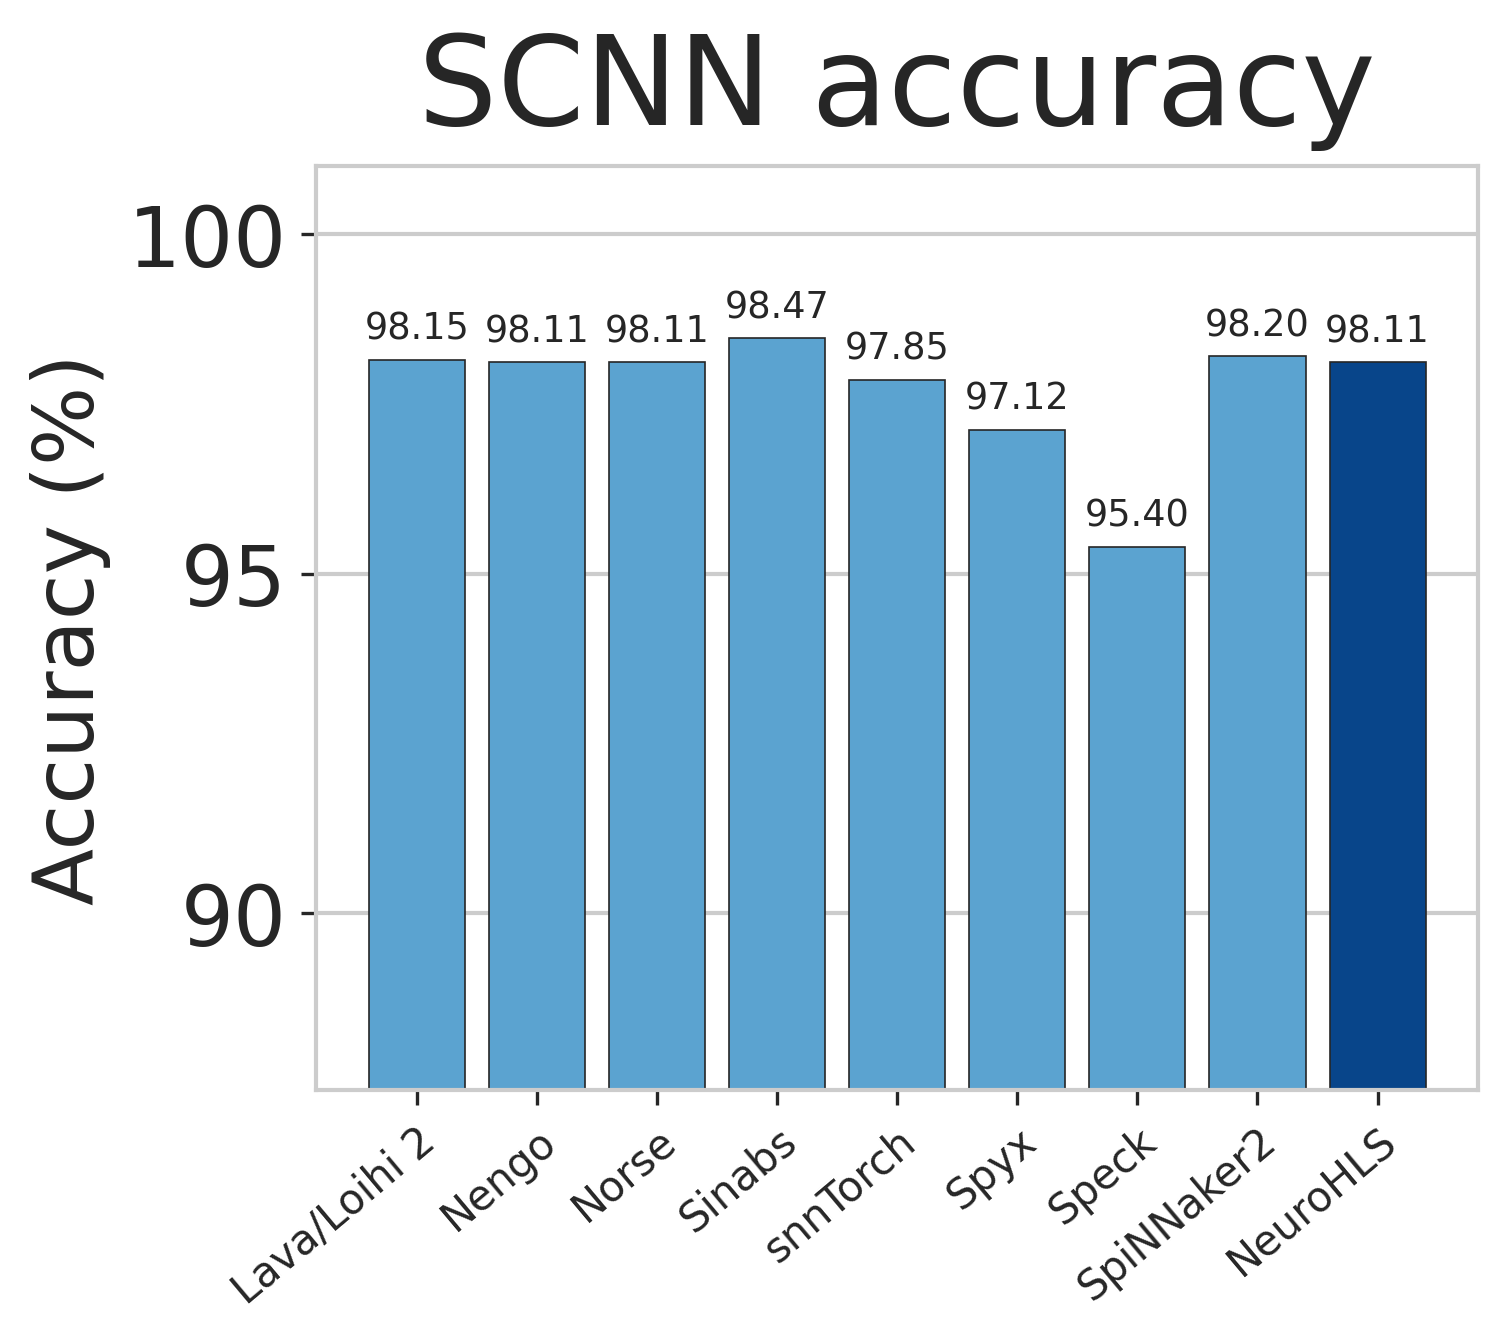

In [4]:
published_accuracy = vc.accuracy_reference('SCNN').copy()
neurohls_accuracy = pd.DataFrame([{
    'experiment': 'SCNN', 'variant': 'N-MNIST',
    'library': f'NeuroHLS',
    'accuracy_percent': accuracy, 'n_samples': accuracy_sample_count,
    'scope': accuracy_scope, 'source': str(accuracy_run_dir),
}])
accuracy_table = pd.concat([published_accuracy, neurohls_accuracy], ignore_index=True)
accuracy_table['directly_comparable_to_published_full_test'] = True
accuracy_table.to_csv(vc.RESULTS_ROOT / 'scnn_accuracy_comparison.csv', index=False)
vc.plot_accuracy(
    accuracy_table,
    'SCNN accuracy',
    vc.RESULTS_ROOT / 'scnn_accuracy_comparison.png',
)
print(accuracy_table.to_string(index=False))


## First-IF activity

The paper's code averages each `(time, sample, channel, y, x)` activity tensor over time and then flattens all samples, channels, and spatial positions. This follows that code for the paper activity set.


sample
0    0.005168
1    0.001626
2    0.004711
3    0.005463
4    0.003063
5    0.004791
6    0.004283
7    0.003230
8    0.004800
9    0.003319


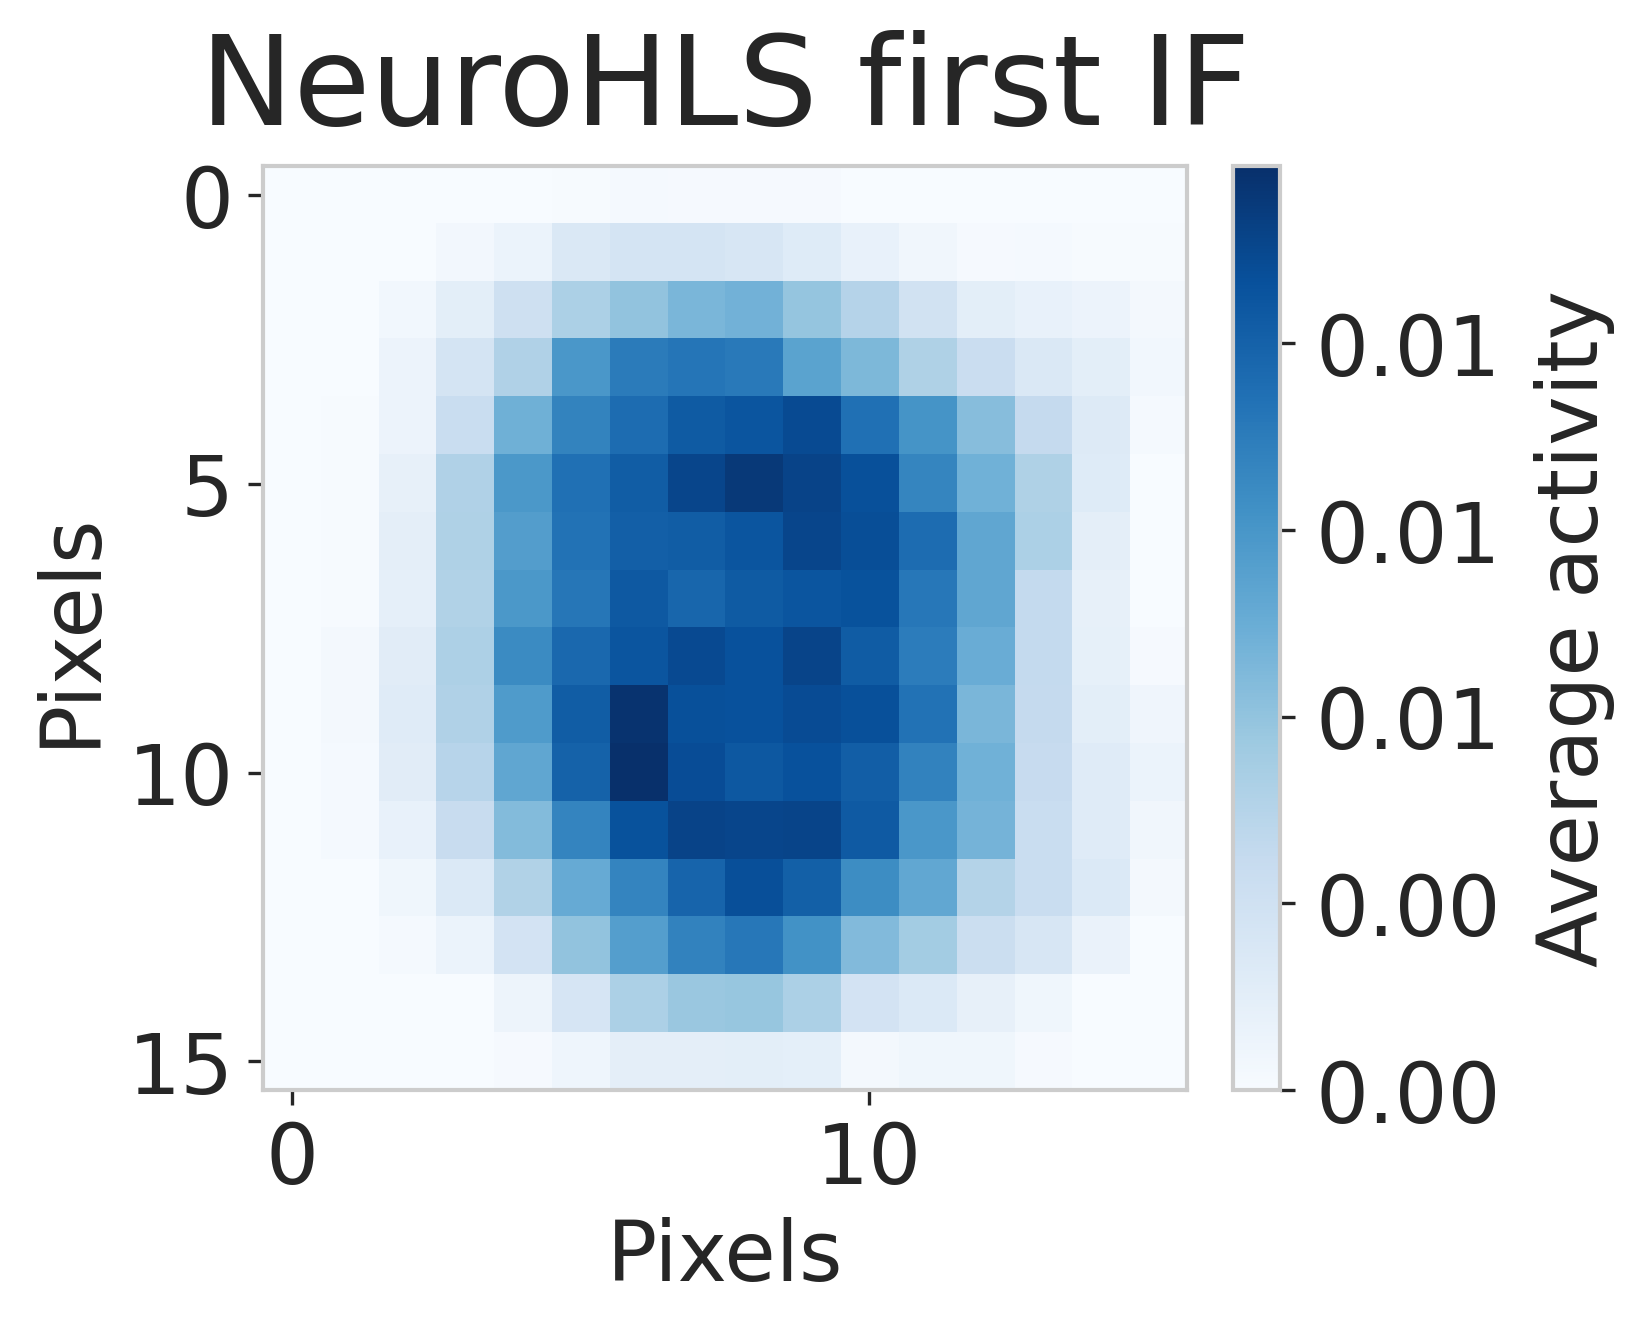

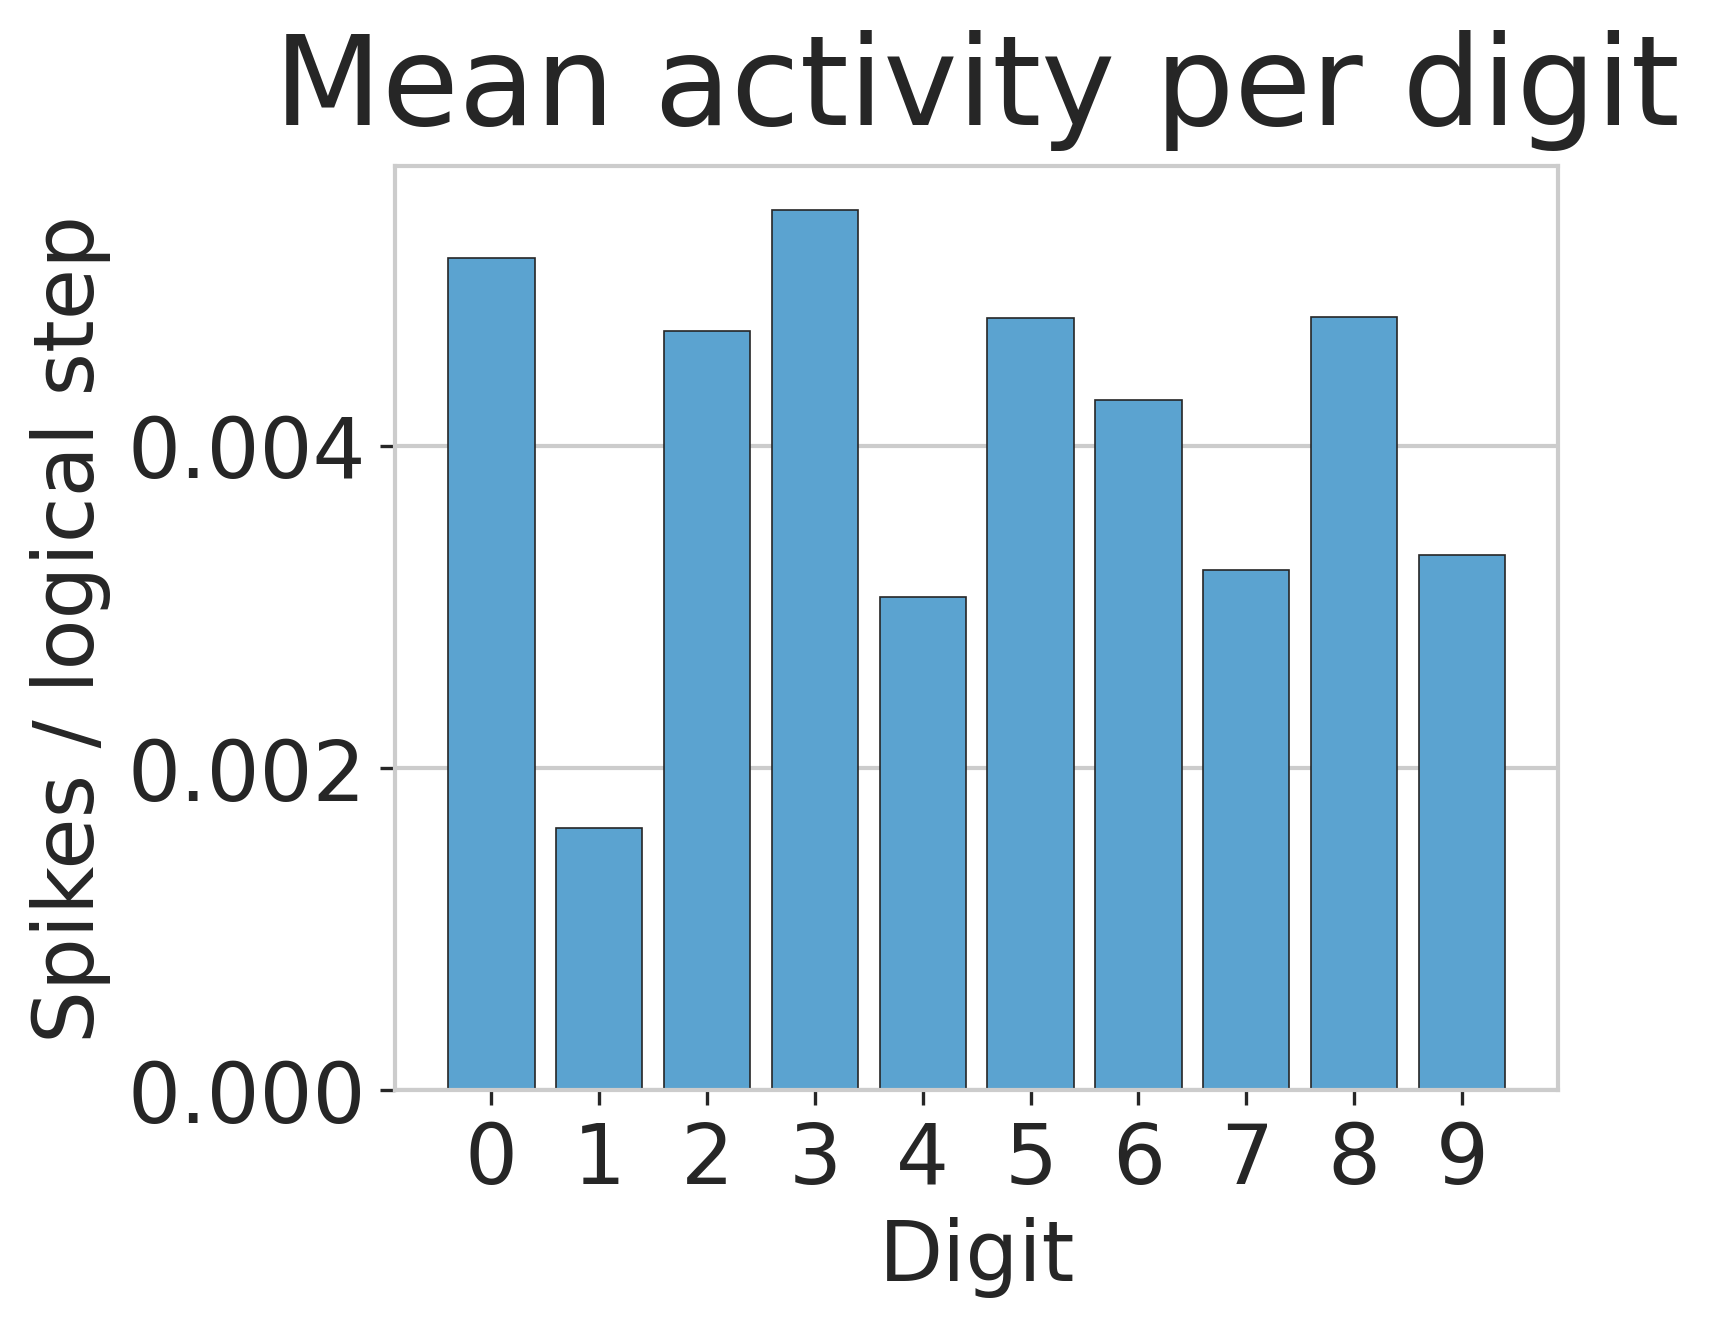

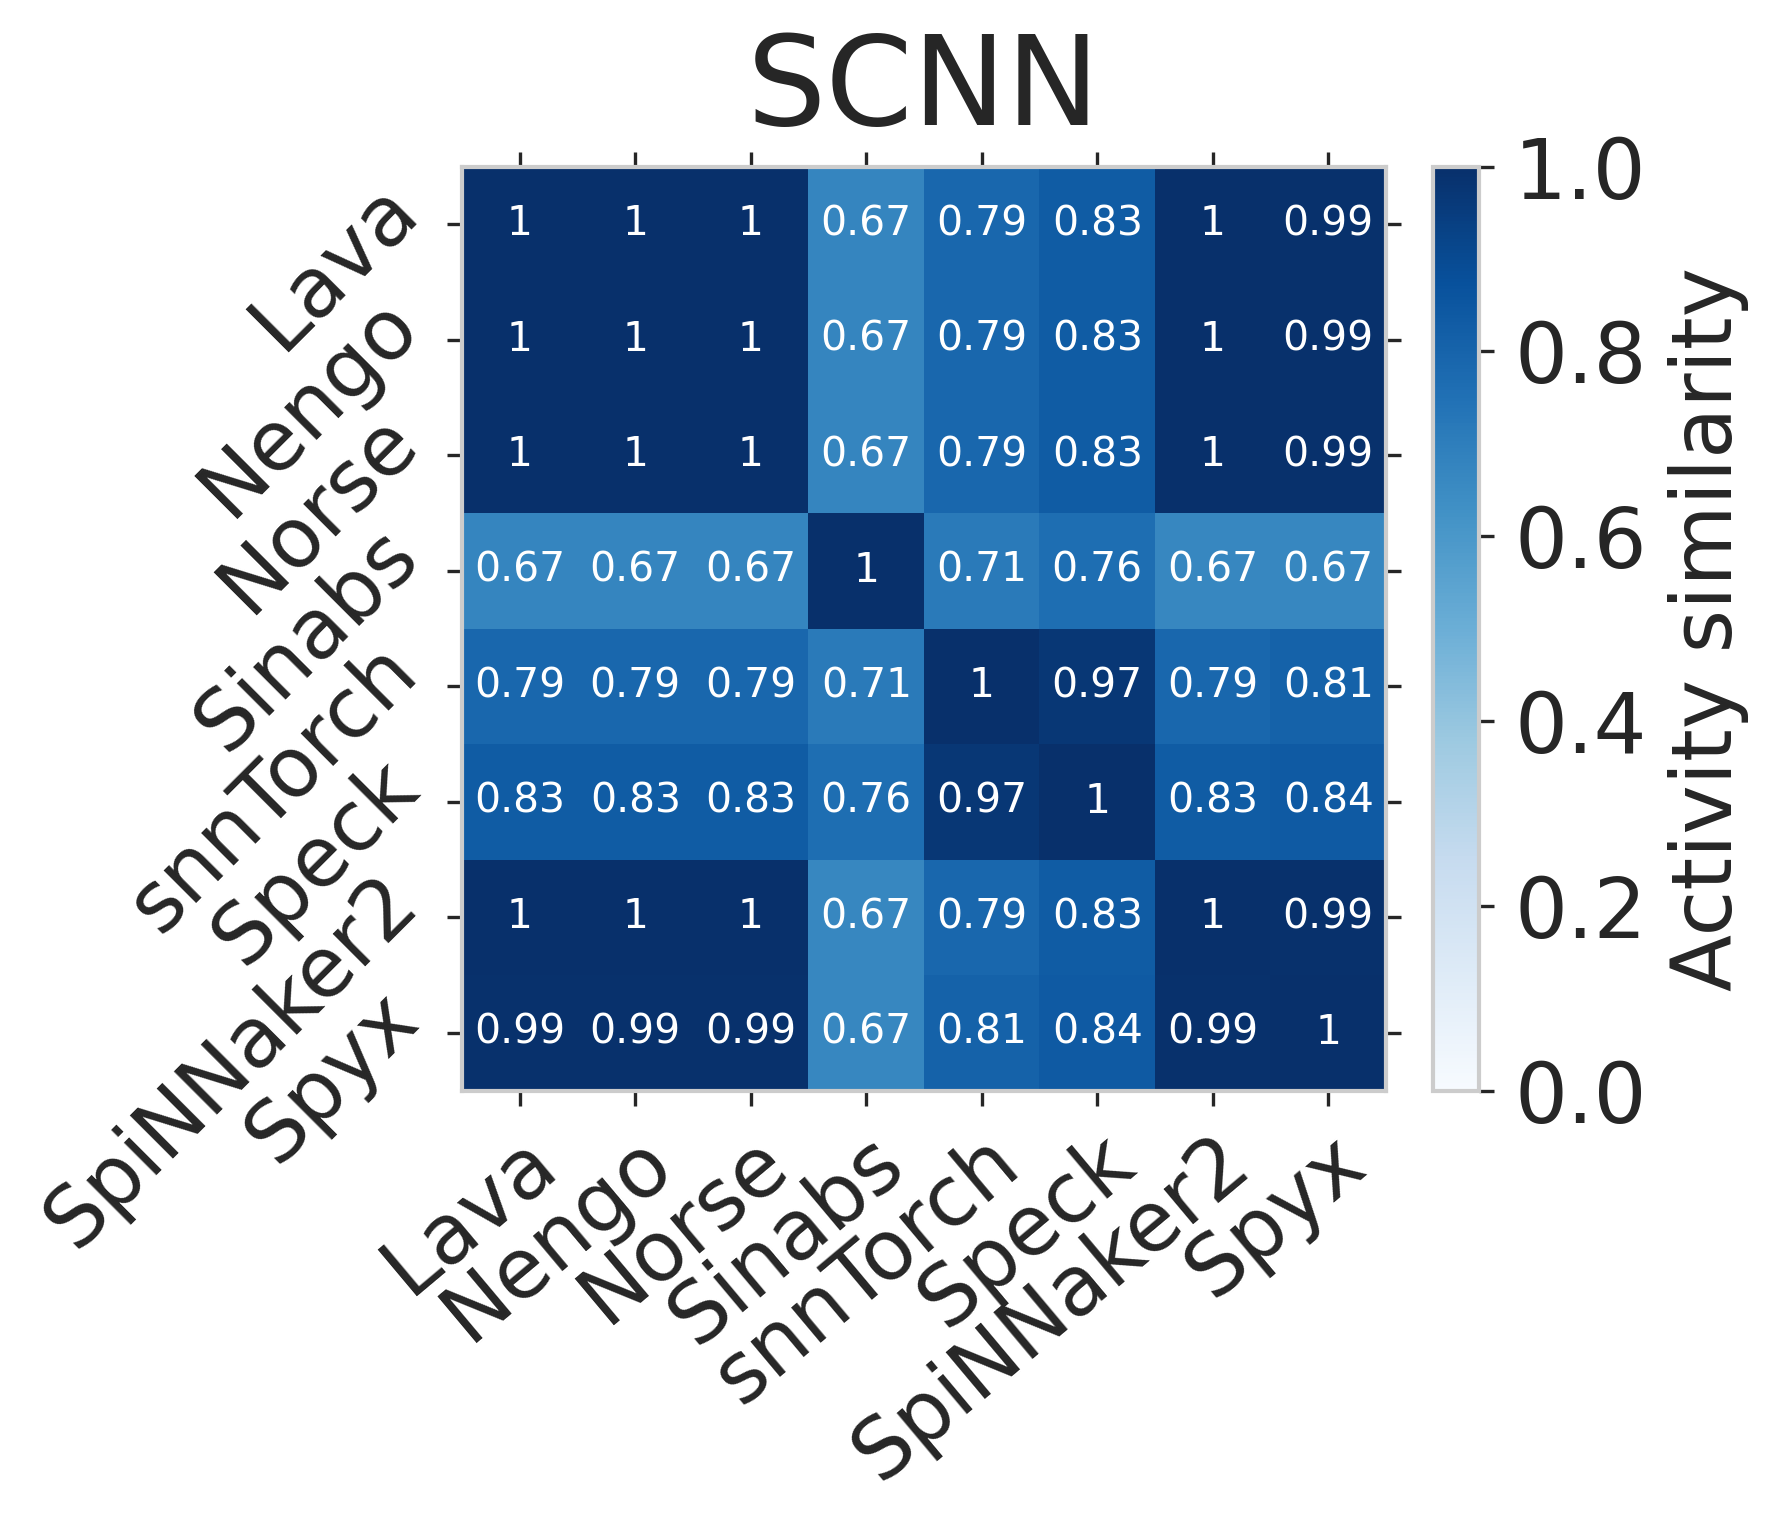

In [ ]:
mean_map = activity_rates.groupby(['y', 'x'], sort=True)['rate'].mean().unstack('x')
per_sample = activity_rates.groupby('sample', sort=True)['rate'].mean()

# One figure per panel, on the paper's 5x4 inch / 300 dpi canvas, matching the
# digit-input plot in nir_paper/02_cnn/cnn_plots.ipynb.
figure, axis = vc.paper_figure()
image = axis.imshow(mean_map.to_numpy(), cmap=vc.PAPER_CMAP, origin='upper')
axis.grid(False)
vc.paper_colorbar(figure, image, axis, 'Average activity', labelpad=8, decimals=2)
axis.set_xlabel('Pixels')
axis.set_ylabel('Pixels')
vc.paper_title(figure, axis, 'NeuroHLS first IF')
vc.save_paper_figure(figure, vc.RESULTS_ROOT / 'scnn_neurohls_first_if_activity.png')

figure, axis = vc.paper_figure()
axis.bar(
    per_sample.index.astype(str), per_sample.to_numpy(),
    color=vc.paper_palette(len(per_sample)), edgecolor='.15', linewidth=0.4,
)
axis.grid(True, axis='y')
axis.grid(False, axis='x')
axis.set_xlabel('Digit')
axis.set_ylabel('Spikes / logical step')
vc.paper_title(figure, axis, 'Mean activity per digit')
vc.save_paper_figure(figure, vc.RESULTS_ROOT / 'scnn_neurohls_first_if_activity_by_digit.png')

published_labels, published_matrix = vc.published_similarity('scnn')
vc.plot_similarity(
    published_labels, published_matrix,
    'SCNN',
    vc.RESULTS_ROOT / 'scnn_published_activity_similarity.png',
)
print(per_sample.to_string())


              Lava   Nengo   Norse  Sinabs  snnTorch   Speck  SpiNNaker2    Spyx  NeuroHLS
Lava        1.0000  1.0000  1.0000  0.6689    0.7884  0.8305      0.9972  0.9942    1.0000
Nengo       1.0000  1.0000  1.0000  0.6689    0.7884  0.8305      0.9972  0.9942    1.0000
Norse       1.0000  1.0000  1.0000  0.6689    0.7884  0.8305      0.9972  0.9942    1.0000
Sinabs      0.6689  0.6689  0.6689  1.0000    0.7143  0.7611      0.6677  0.6657    0.6689
snnTorch    0.7884  0.7884  0.7884  0.7143    1.0000  0.9715      0.7888  0.8059    0.7884
Speck       0.8305  0.8305  0.8305  0.7611    0.9715  1.0000      0.8298  0.8388    0.8305
SpiNNaker2  0.9972  0.9972  0.9972  0.6677    0.7888  0.8298      1.0000  0.9940    0.9972
Spyx        0.9942  0.9942  0.9942  0.6657    0.8059  0.8388      0.9940  1.0000    0.9942
NeuroHLS    1.0000  1.0000  1.0000  0.6689    0.7884  0.8305      0.9972  0.9942    1.0000


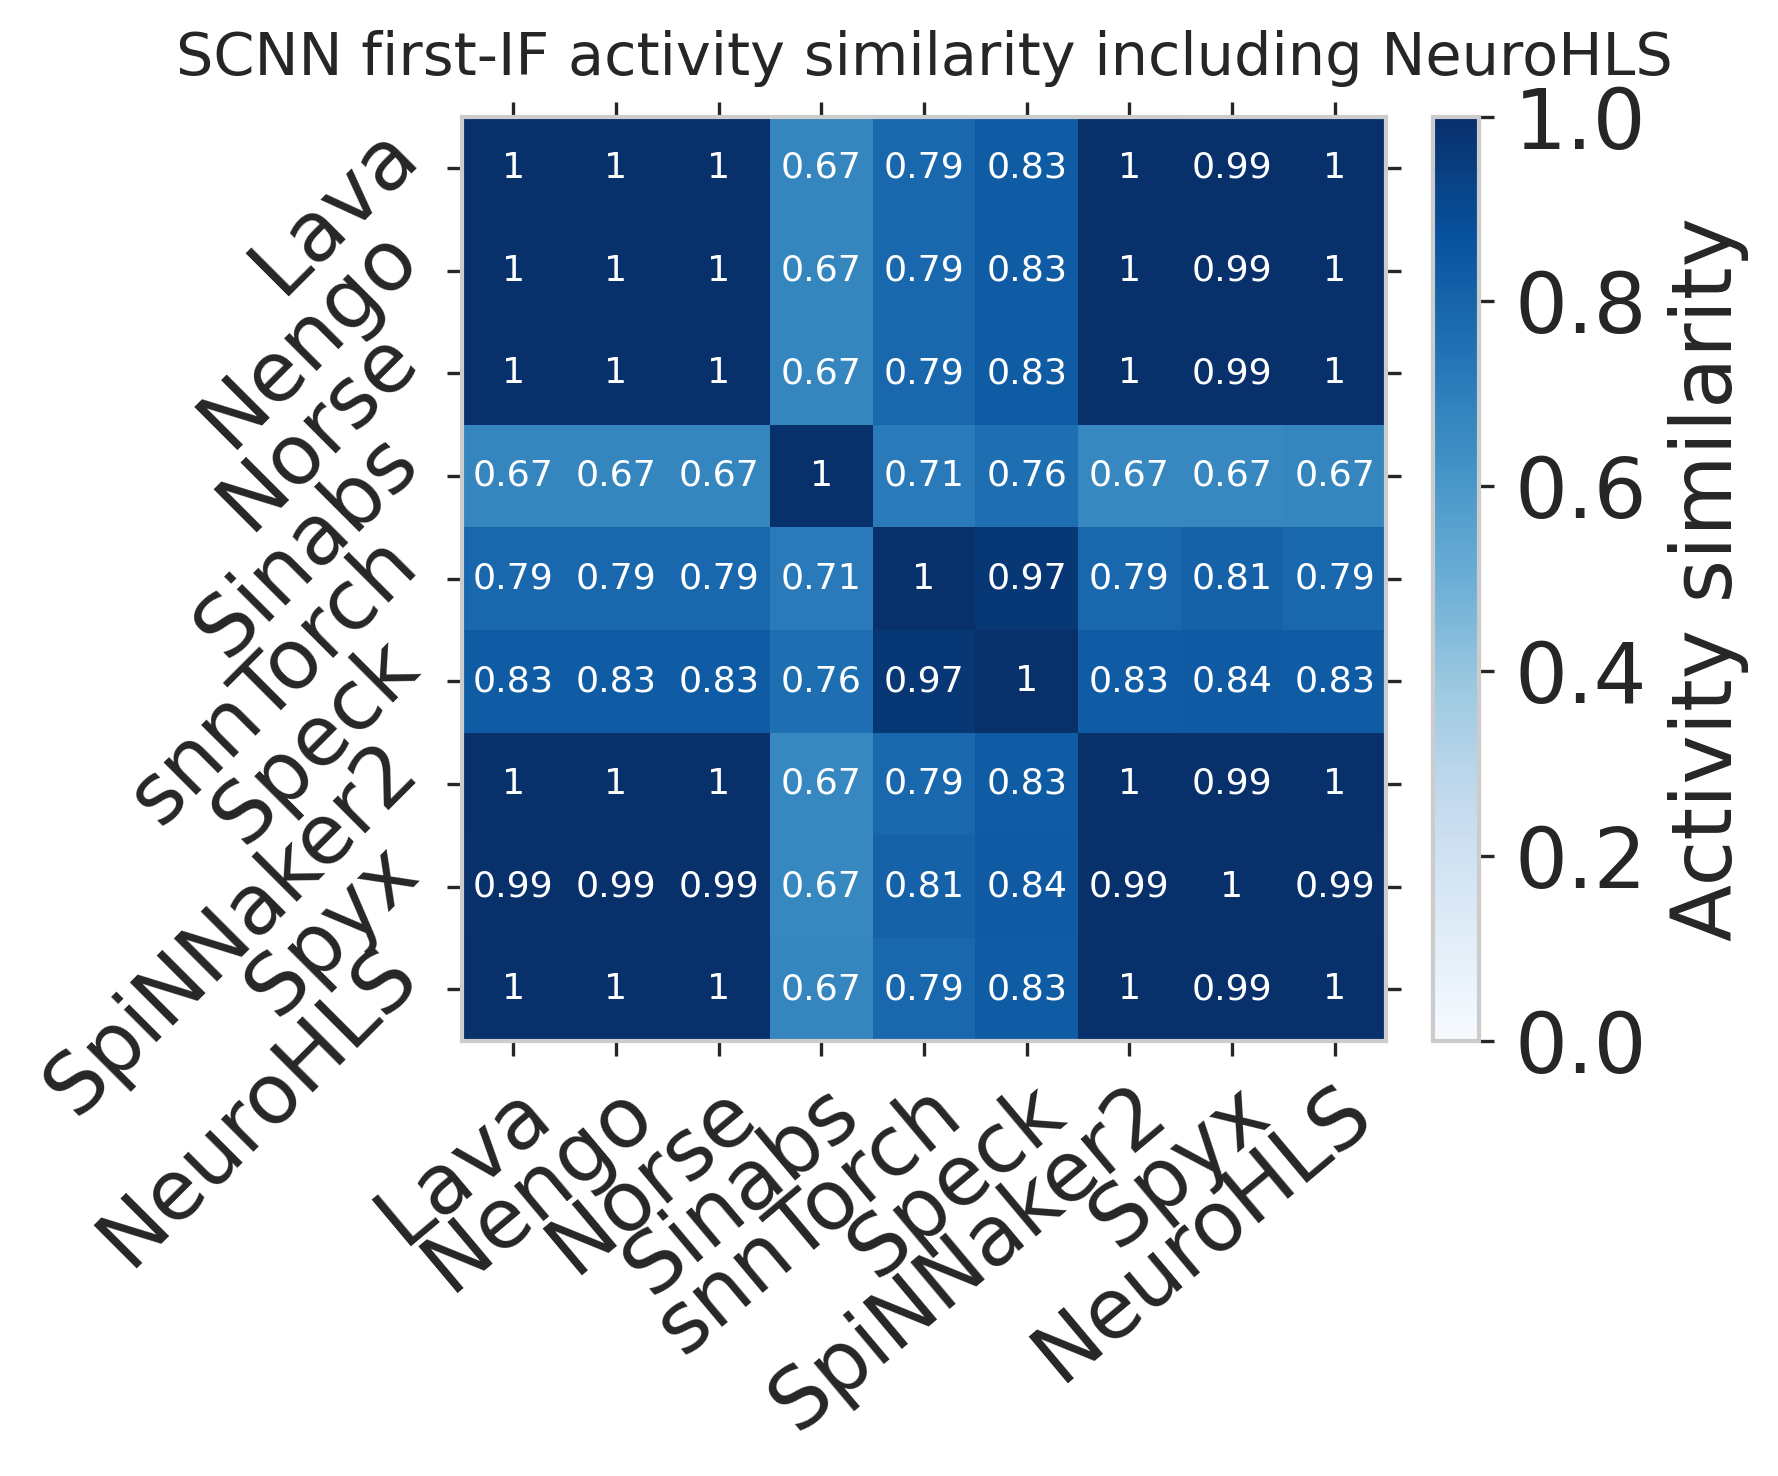

In [6]:
# Adding NeuroHLS to the cosine matrix requires the official activity arrays.
# They are used automatically from a local NIR checkout; a ~500 MB download
# occurs only when explicitly enabled.
can_compare_activity = activity_sample_count == 10 and (vc.locate_paper_root() is not None or ALLOW_LARGE_DOWNLOAD)
if can_compare_activity:
    ordered = activity_rates.sort_values(['sample', 'channel', 'y', 'x'])['rate'].to_numpy()
    reference_rates = vc.load_scnn_reference_rates(allow_large_download=ALLOW_LARGE_DOWNLOAD)
    reference_rates['NeuroHLS'] = ordered
    labels, matrix = vc.cosine_matrix(reference_rates)
    pd.DataFrame(matrix, index=labels, columns=labels).to_csv(vc.RESULTS_ROOT / 'scnn_activity_similarity_with_neurohls.csv')
    vc.plot_similarity(
        labels, matrix, 'SCNN first-IF activity similarity',
        vc.RESULTS_ROOT / 'scnn_activity_similarity_with_neurohls.png',
    )
    print(pd.DataFrame(matrix, index=labels, columns=labels).round(4).to_string())
else:
    print('NeuroHLS was not added to the activity matrix: use all ten activity samples and provide the official activity arrays.')
